# ROGII Wellbore Geology - LSTM Training

Train a Bidirectional LSTM to predict **TVT** from horizontal well logs.

**Features (6):** `MD, X, Y, Z, GR, TVT_input`

**Label:** `TVT`

**Runtime**: Kaggle GPU (T4/P100) - Keras 3 + JAX backend

**Author**: Samir Attrah

In [1]:
# Cell 1: Environment & Imports
import os
os.environ["KERAS_BACKEND"] = "jax"

import jax
# Enable JAX float64 precision natively
jax.config.update("jax_enable_x64", True)

import keras
from keras import layers, callbacks, regularizers
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob, pickle, warnings, random
warnings.filterwarnings("ignore")

# Show enough digits to round-trip float64 diagnostics; this does not round stored values.
np.set_printoptions(precision=17, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")


2026-05-29 10:56:26.742136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780041386.755640  198383 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780041386.759422  198383 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version : 3.12.0
Keras backend : jax
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks


In [2]:
# Cell 2: Auto-detect dataset path

def find_data_dir():
    """Searches common Kaggle mount points for the ROGII dataset.

    Checks competition path, regular dataset path, and local fallback.

    Returns:
        Absolute path to the dataset root directory.

    Raises:
        FileNotFoundError: If no valid dataset is found.
    """
    # Ordered list of candidate paths to check
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    # Also scan /kaggle/input/ for any match
    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            print(f"  X {path}  (does not exist)")
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        has_test = "test" in contents and os.path.isdir(os.path.join(path, "test"))

        # Count CSVs in train/ and test/
        n_train = 0
        if has_train:
            n_train = len(glob.glob(os.path.join(path, "train", "*__horizontal_well.csv")))
        n_test = 0
        if has_test:
            n_test = len(glob.glob(os.path.join(path, "test", "*__horizontal_well.csv")))

        print(f"  -> {path}")
        print(f"    train/: {n_train} wells | test/: {n_test} wells")

        if n_train > 0 or n_test > 0:
            print(f"  V Using this path as DATA_DIR")
            return path
        else:
            print(f"    (no well CSVs found, skipping)")

    raise FileNotFoundError(
        "Could not find ROGII dataset. Checked:\n"
        + "\n".join(f"  - {c}" for c in candidates)
    )

DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  X /kaggle/input/competitions/rogii-wellbore-geology-prediction  (does not exist)
  X /kaggle/input/rogii-wellbore-geology-prediction  (does not exist)
  -> /home/samer/Documents/competitions/ROGII/dataset
    train/: 773 wells | test/: 3 wells
  V Using this path as DATA_DIR


In [3]:
# Cell 3: Configuration

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle") else os.path.abspath(os.path.join(os.getcwd(), "..", "outputs"))
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG = {
    "seed": 42,
    "data_dir": DATA_DIR,
    "model_path": f"{OUT_DIR}/lstm_tvt_model.keras",
    "scaler_path": f"{OUT_DIR}/scaler_params.pkl",
    "window_size": 3,
    "stride": 1,
    "lstm_units_1": 10,
    "lstm_units_2": 10,
    "lstm_units_3": 10,
    "lstm_units_4": 8,
    "lstm_units_5": 8,
    "lstm_units_6": 8,
    "lstm_units_7": 6,
    "lstm_units_8": 6,
    "kr_rate": 5e-5,
    "dense_units": 6,
    "dropout": 0.30,
    "epochs": 25,
    "batch_size": 8,
    "lr": 1e-3,
    "val_ratio": 0.20,
    "max_wells": None,
    "gcn": 1,
}

# --- NEW feature set: 6 raw columns from horizontal_well.csv ---
FEATURE_COLS = [
    "MD", "X", "Y", "Z", "GR", "TVT_input",
]
TARGET = "TVT"

print(f"Data dir   : {CONFIG['data_dir']}")
print(f"Output dir : {OUT_DIR}")
print(f"Model path : {CONFIG['model_path']}")
print(f"Features   : {len(FEATURE_COLS)} columns -> {FEATURE_COLS}")
print(f"Label      : {TARGET}")


Data dir   : /home/samer/Documents/competitions/ROGII/dataset
Output dir : /home/samer/Documents/competitions/ROGII/outputs
Model path : /home/samer/Documents/competitions/ROGII/outputs/lstm_tvt_model.keras
Features   : 6 columns -> ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
Label      : TVT


In [4]:
# Cell 4: Data helpers

def well_ids(data_dir, split="train"):
    """Returns sorted well IDs for a split.

    Args:
        data_dir: Root dataset directory.
        split: Either 'train' or 'test'.

    Returns:
        Sorted list of well ID strings.
    """
    pattern = os.path.join(data_dir, split, "*__horizontal_well.csv")
    ids = sorted(os.path.basename(f).split("__")[0] for f in glob.glob(pattern))
    print(f"  Found {len(ids)} wells in {split}/")
    return ids


def load_well(data_dir, wid, split="train"):
    """Loads one horizontal well CSV as Polars DataFrame.

    Args:
        data_dir: Root dataset directory.
        wid: Well identifier string.
        split: Either 'train' or 'test'.

    Returns:
        Polars DataFrame with all columns from the CSV.
    """
    path = os.path.join(data_dir, split, f"{wid}__horizontal_well.csv")
    return pl.read_csv(path, infer_schema_length=10000)


def preprocess(df):
    """Preprocess a horizontal well DataFrame for the 6-feature set.

    Handles null values in GR and TVT_input (interpolation + forward/backward fill).
    All remaining nulls are filled with 0.0.

    Args:
        df: Raw Polars DataFrame from load_well().

    Returns:
        Polars DataFrame with clean feature columns.
    """
    # GR and TVT_input: linear interpolation then forward/backward fill
    for col in ["GR", "TVT_input"]:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).interpolate()
                  .fill_null(strategy="forward").fill_null(strategy="backward")
                  .fill_null(0.0)
            )

    return df


def make_seqs(feats, tgts, ws, stride):
    """Creates sliding-window sequences from feature and target arrays.

    Uses float64 throughout to preserve full precision of the raw data
    (coordinates X/Y can be ~2.9M, TVT ~11k). The float64 precision
    ensures normalization/denormalization later does not lose significant
    digits.

    Args:
        feats: 2D numpy array of shape (n_rows, n_features).
        tgts: 1D numpy array of shape (n_rows,).
        ws: Window size (sequence length).
        stride: Step between consecutive windows.

    Returns:
        Tuple of (X, y) where X has shape (n_seqs, ws, n_features)
        and y has shape (n_seqs,). Both are float64.
        Includes the final valid window ending at the last row.
    """
    idx = range(0, len(feats) - ws + 1, stride)
    # Allocate in float64 to keep full precision for normalization
    X = np.empty((len(idx), ws, feats.shape[1]), dtype=np.float64)
    y = np.empty(len(idx), dtype=np.float64)
    for i, s in enumerate(idx):
        X[i] = feats[s:s+ws]
        y[i] = tgts[s+ws-1]
    return X, y


# --- Verify data access ---
print("--- Verifying data access ---")
ids = well_ids(CONFIG["data_dir"], "train")
test_ids_check = well_ids(CONFIG["data_dir"], "test")

sample = load_well(CONFIG["data_dir"], ids[0])
print(f"\nSample well: {ids[0]}")
print(f"  Columns: {sample.columns}")
print(f"  Shape  : {sample.shape}")
print(f"  GR nulls : {sample['GR'].null_count()}")
print(f"  TVT nulls: {sample['TVT'].null_count()}")

sample_pp = preprocess(sample)
missing_feats = [c for c in FEATURE_COLS if c not in sample_pp.columns]
if missing_feats:
    print(f"  Missing features after preprocessing: {missing_feats}")
else:
    print(f"  All {len(FEATURE_COLS)} features available")
    print(f"  GR nulls after preprocess: {sample_pp['GR'].null_count()}")


--- Verifying data access ---
  Found 773 wells in train/
  Found 3 wells in test/

Sample well: 000d7d20
  Columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
  Shape  : (5278, 13)
  GR nulls : 2258
  TVT nulls: 0
  All 6 features available
  GR nulls after preprocess: 0


In [5]:
# Cell 5: Prepare training data (HIGH-PRECISION float64 normalization)
#
# Key precision design:
#   1. Raw data is loaded and stored as np.float64 throughout make_seqs()
#   2. Mean/std are computed in float64 -> format nn.nnnnnnnnnnnnnnn
#      (15+ significant digits instead of 7 in float32)
#   3. Normalization (subtract mean, divide by std) is done in float64
#   4. ONLY AFTER normalization, data is cast to float32 for Keras/JAX
#   5. Denormalization at inference uses float64 scaler values
#      to avoid precision loss when multiplying by std and adding mean.

def prepare_data(cfg):
    """Load all training wells, preprocess, create sequences, normalise.

    All normalization statistics are computed and stored in float64 to
    preserve at least 15 significant digits (nn.nnnnnnnnnnnnnnn).
    This prevents precision loss during denormalization, which was causing
    inflated RMSE on the original scale despite low normalized RMSE.

    The pipeline:
      1. Load raw data -> float64
      2. Compute mean/std in float64 (full 16-digit precision)
      3. Normalize in float64 (high-quality division)
      4. Cast to float32 only for model input
      5. Save scaler params as float64 for exact denormalization later

    Args:
        cfg: Configuration dictionary with keys 'data_dir',
             'max_wells', 'val_ratio', 'window_size', 'stride'.

    Returns:
        Tuple of (X_train, y_train, X_val, y_val, y_val_raw, scaler)
        where scaler is a dict with float64 normalisation parameters.
    """
    ids_all = well_ids(cfg["data_dir"], "train")
    if cfg["max_wells"]:
        ids_all = ids_all[:cfg["max_wells"]]
        print(f"  (limited to {cfg['max_wells']} wells)")
    ws = cfg["window_size"]

    # Well-level train/val split
    np.random.seed(cfg.get("seed", 42))
    n_val = max(1, int(len(ids_all) * cfg["val_ratio"]))
    val_set = set(np.random.permutation(len(ids_all))[:n_val])
    print(f"  Train wells: {len(ids_all) - n_val}, Val wells: {n_val}")

    Xt, yt, Xv, yv = [], [], [], []
    skipped = 0
    for i, wid in enumerate(ids_all):
        if (i+1) % 100 == 0:
            print(f"  Processing well {i+1}/{len(ids_all)}...")
        try:
            df = preprocess(load_well(cfg["data_dir"], wid))

            # Filter rows where TVT is available
            df = df.filter(pl.col(TARGET).is_not_null())
            if len(df) <= ws:
                skipped += 1
                continue

            # Extract features and target in float64 for precision
            f = np.nan_to_num(
                df.select(FEATURE_COLS).to_numpy().astype(np.float64)
            )
            t = np.nan_to_num(
                df.select(TARGET).to_numpy().ravel().astype(np.float64)
            )

            X, y = make_seqs(f, t, ws, cfg["stride"])
            (Xv if i in val_set else Xt).append(X)
            (yv if i in val_set else yt).append(y)
        except Exception as e:
            skipped += 1
            print(f"  Skip {wid}: {e}")

    # Concatenate in float64
    Xt, yt = np.concatenate(Xt), np.concatenate(yt)
    Xv, yv = np.concatenate(Xv), np.concatenate(yv)

    print(f"\n  Wells skipped: {skipped}")
    print(f"  Train sequences: {Xt.shape}")
    print(f"  Val sequences  : {Xv.shape}")

    # ====================================================================
    # Z-score normalisation — ALL computed in float64
    # This gives us mean/std with ~15 significant digits, e.g.:
    #   feat_mean[0] = 12935.971234567890 (not 12935.97 as float32)
    # ====================================================================
    mu = Xt.mean(axis=(0, 1))        # float64 mean per feature
    sigma = Xt.std(axis=(0, 1)) + 1e-15  # float64 std + tiny epsilon

    # Normalize in float64 (preserves precision in the division)
    Xt_normed = (Xt - mu) / sigma
    Xv_normed = (Xv - mu) / sigma

    # Target normalisation in float64
    ym = yt.mean()                # float64
    ys = yt.std() + 1e-15         # float64

    # Print with full float64 precision to verify
    print(f"\n  [float64 precision] Feature means:")
    for idx_f, col in enumerate(FEATURE_COLS):
        print(f"    {col:>12s}: {repr(mu[idx_f])}")
    print(f"  [float64 precision] Feature stds:")
    for idx_f, col in enumerate(FEATURE_COLS):
        print(f"    {col:>12s}: {repr(sigma[idx_f])}")
    print(f"  [float64 precision] Target mean : {repr(ym)}")
    print(f"  [float64 precision] Target std  : {repr(ys)}")

    # Verify roundtrip precision: denormalize a sample and compare
    sample_raw = yt[:5]
    sample_norm = (sample_raw - ym) / ys
    sample_denorm = sample_norm * ys + ym
    roundtrip_err = np.max(np.abs(sample_raw - sample_denorm))
    print(f"  Roundtrip denorm max error: {repr(float(roundtrip_err))}")

    # Build scaler dict — store everything as float64
    scaler = {
        "feat_mean": mu,            # np.float64 array
        "feat_std": sigma,          # np.float64 array
        "target_mean": ym,          # np.float64 scalar
        "target_std": ys,           # np.float64 scalar
        "feature_cols": FEATURE_COLS,
    }

    # Cast to float32 ONLY for model input (after normalization)
    X_train_f32 = Xt_normed.astype(np.float32)
    y_train_f32 = ((yt - ym) / ys).astype(np.float32)
    X_val_f32 = Xv_normed.astype(np.float32)
    y_val_f32 = ((yv - ym) / ys).astype(np.float32)

    # Keep y_val_raw in float64 for precise RMSE comparison
    y_val_raw_f64 = yv  # already float64

    return X_train_f32, y_train_f32, X_val_f32, y_val_f32, y_val_raw_f64, scaler


print("--- Loading and preparing training data ---")
X_train, y_train, X_val, y_val, y_val_raw, scaler = prepare_data(CONFIG)

with open(CONFIG["scaler_path"], "wb") as f:
    pickle.dump(scaler, f)
print(f"\nScaler saved: {CONFIG['scaler_path']}")
print(f"Scaler dtypes:")
print(f"  feat_mean  dtype: {scaler['feat_mean'].dtype}")
print(f"  feat_std   dtype: {scaler['feat_std'].dtype}")
print(f"  target_mean type: {type(scaler['target_mean']).__name__} = {repr(scaler['target_mean'])}")
print(f"  target_std  type: {type(scaler['target_std']).__name__} = {repr(scaler['target_std'])}")


--- Loading and preparing training data ---
  Found 773 wells in train/
  Train wells: 619, Val wells: 154
  Processing well 100/773...
  Processing well 200/773...
  Processing well 300/773...
  Processing well 400/773...
  Processing well 500/773...
  Processing well 600/773...
  Processing well 700/773...

  Wells skipped: 0
  Train sequences: (4053660, 3, 6)
  Val sequences  : (1037049, 3, 6)

  [float64 precision] Feature means:
              MD: np.float64(14289.749232792094)
               X: np.float64(2966404.6469662953)
               Y: np.float64(1075561.2252413006)
               Z: np.float64(-9379.250329212378)
              GR: np.float64(88.38146519082242)
       TVT_input: np.float64(11491.414559573586)
  [float64 precision] Feature stds:
              MD: np.float64(2196.058159173113)
               X: np.float64(48008.34864262299)
               Y: np.float64(35213.75066940013)
               Z: np.float64(633.680868895357)
              GR: np.float64(23.3421321377

In [ ]:
# Cell 6: Build & train BiLSTM model

def build_model(input_shape, cfg):
    """Builds a Bidirectional LSTM regression model for TVT prediction.

    Architecture: BiLSTM -> BN -> BiLSTM -> BN -> Dense -> Dropout -> Dense(1)

    Args:
        input_shape: Tuple of (window_size, n_features).
        cfg: Configuration dict with model hyperparameters.

    Returns:
        Compiled Keras model.
    """
    inp = keras.Input(shape=input_shape)
    x = layers.LSTM(cfg["lstm_units_1"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(inp)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_2"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_3"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_4"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_5"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_6"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_7"], return_sequences=True, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.LSTM(cfg["lstm_units_8"], return_sequences=False, kernel_regularizer=regularizers.L2(cfg["kr_rate"]),dropout=cfg["dropout"])(x)
    # x = layers.BatchNormalization()(x)
    x = layers.Dense(cfg["dense_units"], activation="relu")(x)
    x = layers.Dropout(cfg["dropout"])(x)
    out = layers.Dense(1, activation="linear")(x)
    m = keras.Model(inp, out, name="BiLSTM_TVT")
    m.compile(
        optimizer=keras.optimizers.Adam(cfg["lr"], global_clipnorm=cfg["gcn"]),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return m


input_shape = (CONFIG["window_size"], len(FEATURE_COLS))
print(f"Building model with input shape: {input_shape}")
model = build_model(input_shape, CONFIG)
model.summary()

cbs = [
    # callbacks.EarlyStopping(
    #     monitor="val_rmse", patience=20,
    #     restore_best_weights=True, mode="min"),
    callbacks.ModelCheckpoint(
        CONFIG["model_path"], monitor="val_rmse",
        save_best_only=True, mode="min"),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5,
        patience=3, min_lr=1e-6),
]

print(f"\nStarting training: {CONFIG['epochs']} epochs, batch={CONFIG['batch_size']}")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=cbs,
)
print(f"\nTraining complete. Best model saved to {CONFIG['model_path']}")


Building model with input shape: (3, 6)


Model: "BiLSTM_TVT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 3, 10)          │           680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 10)          │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 3, 10)          │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 3, 8)           │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 3, 8)           │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 3, 8)           │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 3, 6)           │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 6)              │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,777 (18.66 KB)

 Trainable params: 4,777 (18.66 KB)

 Non-trainable params: 0 (0.00 B)


Starting training: 25 epochs, batch=8
Epoch 1/25
506708/506708 ━━━━━━━━━━━━━━━━━━━━ 1472s 3ms/step - loss: 1.0002 - rmse: 1.0001 - val_loss: 1.0442 - val_rmse: 1.0219 - learning_rate: 0.0010
Epoch 2/25
506708/506708 ━━━━━━━━━━━━━━━━━━━━ 1636s 3ms/step - loss: 1.0002 - rmse: 1.0001 - val_loss: 1.0462 - val_rmse: 1.0228 - learning_rate: 0.0010
Epoch 3/25
310599/506708 ━━━━━━━━━━━━━━━━━━━━ 8:45 3ms/step - loss: 1.0005 - rmse: 1.0002

Reloaded best model from: /home/samer/Documents/competitions/ROGII/outputs/lstm_tvt_model.keras
64787/64787 ━━━━━━━━━━━━━━━━━━━━ 91s 1ms/step
Prediction sample (float64, unrounded): [10901.819025343011 10903.23976372405  10903.991655883923
 10905.367227598113 10905.704041885176]

Val RMSE (window-level, original scale, unrounded): 205.67822812548647
Val MAE  (window-level, original scale, unrounded): 171.67802330410663
  Found 773 wells in train/

Val RMSE (row-level inference-style, unrounded): 205.75430461361125
Val MAE  (row-level inference-style, unrounded): 171.73439585859188


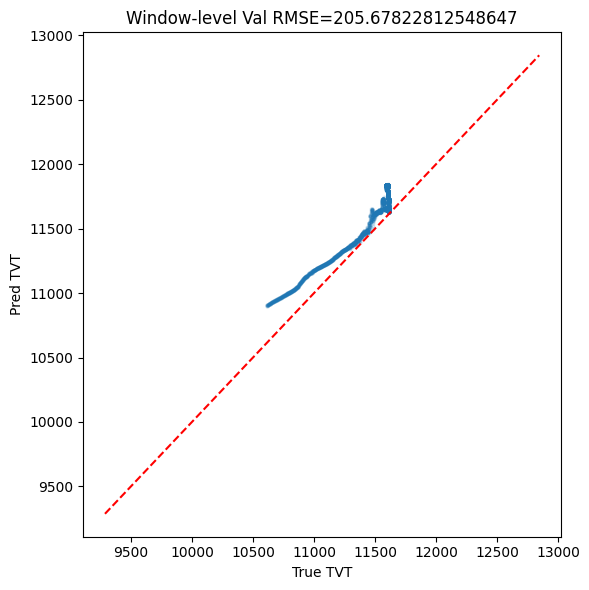

Model saved: /home/samer/Documents/competitions/ROGII/outputs/lstm_tvt_model.keras
Scaler saved: /home/samer/Documents/competitions/ROGII/outputs/scaler_params.pkl
Feature cols stored in scaler: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
Proceed to 02_lstm_inference.ipynb


In [ ]:
# Cell 7: Evaluate & plot (float64 denormalization for precise RMSE)

import matplotlib.pyplot as plt

# Reload the best checkpoint so final validation matches the saved artifact
best_model = keras.saving.load_model(CONFIG["model_path"])
print(f"Reloaded best model from: {CONFIG['model_path']}")

# Window-level validation (same tensors used during training)
# Denormalize in JAX float64 to preserve full precision of scaler params
yn_raw = best_model.predict(X_val, batch_size=16).ravel()
# Cast model output to JAX float64 BEFORE multiplying by float64 scaler values
yn_f64 = jnp.array(yn_raw, dtype=jnp.float64)
t_mean = jnp.array(scaler["target_mean"], dtype=jnp.float64)
t_std = jnp.array(scaler["target_std"], dtype=jnp.float64)
yp = np.array(yn_f64 * t_std + t_mean, dtype=np.float64)
print("Prediction sample (float64, unrounded):", np.array2string(yp[:5], precision=17, floatmode="unique"))

# y_val_raw is already float64 from prepare_data()
err = jnp.array(yp, dtype=jnp.float64) - jnp.array(y_val_raw, dtype=jnp.float64)
rmse = float(jnp.sqrt(jnp.mean(err ** 2)))
mae = float(jnp.mean(jnp.abs(err)))
print(f"\nVal RMSE (window-level, original scale, unrounded): {repr(rmse)}")
print(f"Val MAE  (window-level, original scale, unrounded): {repr(mae)}")

# Row-level validation using the same reconstruction logic as inference

def predict_well(model, df, scaler, ws):
    """Predicts TVT for every row of a well log using sliding windows.

    All mathematical operations (normalization, denormalization, windowing)
    are performed in double-precision (float64) using JAX to eliminate
    precision loss from large features and target values.

    Args:
        model: Trained Keras model.
        df (pl.DataFrame): Preprocessed well log DataFrame.
        scaler (dict): Dictionary with float64 normalisation stats.
        ws (int): Window size.

    Returns:
        np.ndarray: 1D float64 array of predictions matching well log length,
            with NaN values for early timesteps.
    """
    # Load features in float64 using JAX
    raw_feats = df.select(FEATURE_COLS).to_numpy()
    feats = jnp.nan_to_num(jnp.array(raw_feats, dtype=jnp.float64))

    # Normalize features in float64 using JAX
    mean = jnp.array(scaler["feat_mean"], dtype=jnp.float64)
    std = jnp.array(scaler["feat_std"], dtype=jnp.float64)
    feats_n = (feats - mean) / std

    n = len(feats_n)
    preds = np.full(n, np.nan, dtype=np.float64)
    # Inclusive final-window indexing: the last window ends at the last row.
    starts = list(range(0, n - ws + 1))
    if not starts:
        return preds

    # Stack windows and cast to float32 only for model prediction
    stacked_list = [feats_n[s:s+ws] for s in starts]
    X_jax = jnp.stack(stacked_list)
    X = np.array(X_jax, dtype=np.float32)

    # Model prediction
    yn = model.predict(X, batch_size=512, verbose=0).ravel()

    # Denormalize in float64 using JAX
    yn_f64 = jnp.array(yn, dtype=jnp.float64)
    t_mean = jnp.array(scaler["target_mean"], dtype=jnp.float64)
    t_std = jnp.array(scaler["target_std"], dtype=jnp.float64)
    yp_jax = yn_f64 * t_std + t_mean
    yp = np.array(yp_jax, dtype=np.float64)

    for i, s in enumerate(starts):
        preds[s + ws - 1] = yp[i]

    # Backfill early timesteps
    fv = ws - 1
    if fv < n and not np.isnan(preds[fv]):
        preds[:fv] = preds[fv]

    return preds

ids_all = well_ids(CONFIG["data_dir"], "train")
if CONFIG["max_wells"]:
    ids_all = ids_all[:CONFIG["max_wells"]]
np.random.seed(CONFIG.get("seed", 42))
n_val = max(1, int(len(ids_all) * CONFIG["val_ratio"]))
val_idx = set(np.random.permutation(len(ids_all))[:n_val])
val_ids = [wid for i, wid in enumerate(ids_all) if i in val_idx]

row_true, row_pred = [], []
for wid in val_ids:
    df = preprocess(load_well(CONFIG["data_dir"], wid)).filter(pl.col(TARGET).is_not_null())
    if len(df) <= CONFIG["window_size"]:
        continue
    preds = predict_well(best_model, df, scaler, CONFIG["window_size"])
    true = np.nan_to_num(df.select(TARGET).to_numpy().ravel().astype(np.float64))
    valid = ~np.isnan(preds)
    if np.any(valid):
        row_true.append(true[valid])
        row_pred.append(preds[valid])

if row_true:
    row_true = np.concatenate(row_true)
    row_pred = np.concatenate(row_pred)
    row_err = jnp.array(row_pred, dtype=jnp.float64) - jnp.array(row_true, dtype=jnp.float64)
    row_rmse = float(jnp.sqrt(jnp.mean(row_err ** 2)))
    row_mae = float(jnp.mean(jnp.abs(row_err)))
    print(f"\nVal RMSE (row-level inference-style, unrounded): {repr(row_rmse)}")
    print(f"Val MAE  (row-level inference-style, unrounded): {repr(row_mae)}")
else:
    print("\nVal RMSE (row-level inference-style): skipped, no valid validation wells")

# Scatter: predicted vs actual TVT
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val_raw[:5000], yp[:5000], alpha=0.15, s=4)
lim = [min(y_val_raw.min(), yp.min()), max(y_val_raw.max(), yp.max())]
ax.plot(lim, lim, "r--")
ax.set_xlabel("True TVT")
ax.set_ylabel("Pred TVT")
ax.set_title(f"Window-level Val RMSE={repr(rmse)}")
plt.tight_layout(); plt.show()

print(f"Model saved: {CONFIG['model_path']}")
print(f"Scaler saved: {CONFIG['scaler_path']}")
print(f"Feature cols stored in scaler: {scaler['feature_cols']}")
print("Proceed to 02_lstm_inference.ipynb")
